# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Muhammad Dzaky Haidar |5054251039|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

In [7]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.

df = pd.read_csv("mushrooms.csv", na_values="?")
display(df.head())

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [8]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
df.shape, df.info(), df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                5644 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

((8124, 23),
 None,
 class                          0
 cap-shape                      0
 cap-surface                    0
 cap-color                      0
 bruises                        0
 odor                           0
 gill-attachment                0
 gill-spacing                   0
 gill-size                      0
 gill-color                     0
 stalk-shape                    0
 stalk-root                  2480
 stalk-surface-above-ring       0
 stalk-surface-below-ring       0
 stalk-color-above-ring         0
 stalk-color-below-ring         0
 veil-type                      0
 veil-color                     0
 ring-number                    0
 ring-type                      0
 spore-print-color              0
 population                     0
 habitat                        0
 dtype: int64)

In [9]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
display(df.drop(columns="class").nunique().rename("Unik"))

,Unik
cap-shape,6
cap-surface,4
cap-color,10
bruises,2
odor,9
gill-attachment,2
gill-spacing,2
gill-size,2
gill-color,12
stalk-shape,2


,Proporsi
class,
e,0.517971
p,0.482029


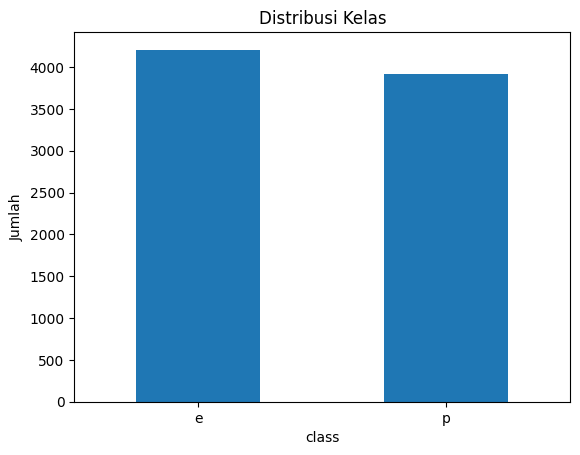

In [10]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
display(df["class"].value_counts(normalize=True).rename("Proporsi"))
df["class"].value_counts().plot.bar(title="Distribusi Kelas", rot=0)

plt.ylabel("Jumlah")
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [11]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.
df = df.fillna("Unknown")
print("Sisa Missing Value:", df.isna().sum().sum())

Sisa Missing Value: 0


In [12]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.
constant = df.drop(columns="class").nunique()
constant = constant[constant == 1].index
print("Fitur yg di Hapus:", constant.tolist())
df = df.drop(columns=constant)

Fitur yg di Hapus: ['veil-type']


In [14]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns="class")
y = df["class"].map({"e": 0, "p": 1})
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (6499, 21) Test: (1625, 21)


In [15]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.

ordinal = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_cat = ordinal.fit_transform(X_train).astype(int) + 1
X_test_cat = ordinal.transform(X_test).astype(int) + 1

In [16]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.

onehot = OneHotEncoder(handle_unknown="ignore")
X_train_hot = onehot.fit_transform(X_train)
X_test_hot = onehot.transform(X_test)

# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [17]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.

cat = CategoricalNB(min_categories=[len(c) + 1 for c in ordinal.categories_])
cat.fit(X_train_cat, y_train)

CategoricalNB(min_categories=[7, 5, 11, 3, 10, 3, 3, 3, 13, 3, 6, 5, 5, 10, 10,
                              5, 4, 6, 10, 7, 8])

In [18]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
pred_cat = cat.predict(X_test_cat)
prob_cat = cat.predict_proba(X_test_cat)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [19]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
ber = BernoulliNB()
ber.fit(X_train_hot, y_train)

BernoulliNB()

In [25]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
pred_ber = ber.predict(X_test_hot)
prob_ber = ber.predict_proba(X_test_hot)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [21]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
mul = MultinomialNB()
mul.fit(X_train_hot, y_train)

MultinomialNB()

In [22]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
pred_mul = mul.predict(X_test_hot)
prob_mul = mul.predict_proba(X_test_hot)[:, 1]


# 4. Evaluasi Model

In [26]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

results = {
    "Categorical NB": (pred_cat, prob_cat),
    "Bernoulli NB": (pred_ber, prob_ber),
    "Multinomial NB": (pred_mul, prob_mul)
}

scores = pd.DataFrame({
    name: {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, prob)
    }
    for name, (pred, prob) in results.items()
}).T

display(scores.round(4))

,Accuracy,Precision,Recall,F1,AUC
Categorical NB,0.9458,0.9901,0.8966,0.9410,0.9972
Bernoulli NB,0.9329,0.9814,0.8774,0.9265,0.9954
Multinomial NB,0.9458,0.9901,0.8966,0.9410,0.9972


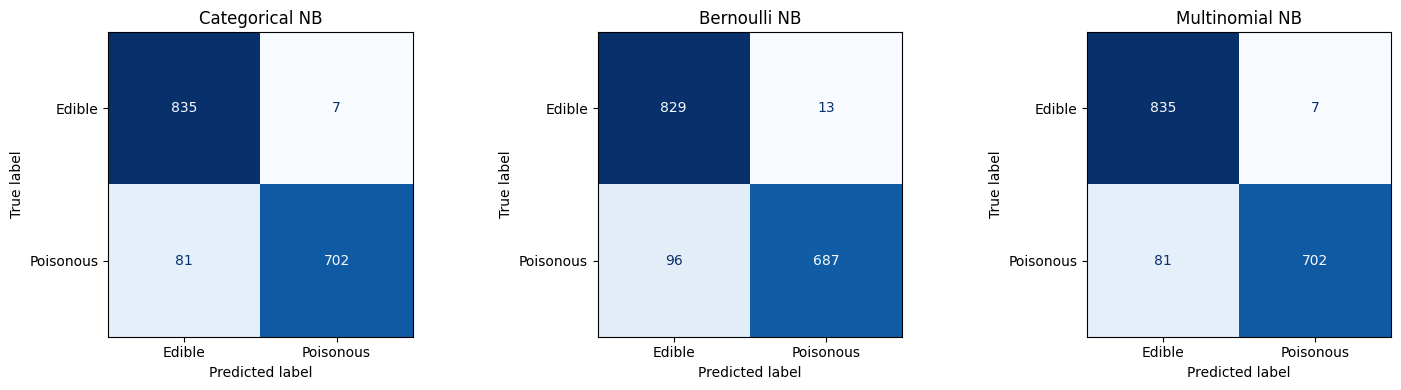

In [27]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, (pred, _)) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=[0, 1], display_labels=["Edible", "Poisonous"], cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

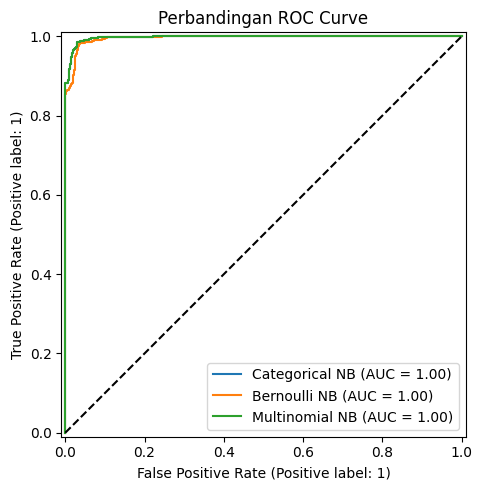

In [29]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
fig, ax = plt.subplots(figsize=(6,5))
for name, (_, prob) in results.items():
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=ax)

ax.plot([0,1], [0,1], "k--")
ax.set_title("Perbandingan ROC Curve")
plt.tight_layout()
plt.show()

# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

1. Dataset terdiri atas 8.124 data dengan proporsi edible 51,80% dan poisonous 48,20%, sehingga distribusi kelas relatif seimbang. Sebanyak 2.480 missing value pada stalk-root dijadikan kategori Unknown, sedangkan fitur veil-type dihapus karena hanya memiliki satu kategori.

2. Data dibagi menjadi 6.499 data train dan 1.625 data test menggunakan stratifikasi. Categorical NB menggunakan OrdinalEncoder, sedangkan Bernoulli NB dan Multinomial NB menggunakan OneHotEncoder. Encoder hanya di-fit pada data train untuk menghindari kebocoran informasi dari data test.

3. Categorical NB dan Multinomial NB menghasilkan performa terbaik dengan accuracy 94,58%, precision 99,01%, recall 89,66%, F1-Score 0,9410, dan AUC 0,9972. Hasil keduanya sama pada pembulatan empat desimal. Bernoulli NB memperoleh accuracy 93,29%, precision 98,14%, recall 87,74%, F1-Score 0,9265, dan AUC 0,9954.

4. Confusion matrix menunjukkan bahwa Categorical NB dan Multinomial NB sama-sama memprediksi 835 jamur edible dan 702 jamur poisonous dengan benar. Kesalahannya berupa 7 jamur edible yang diprediksi poisonous dan 81 jamur poisonous yang diprediksi edible. Bernoulli NB menghasilkan lebih banyak kesalahan, yaitu 13 jamur edible diprediksi poisonous dan 96 jamur poisonous diprediksi edible.

5. Perbedaan performa berkaitan dengan representasi dan perhitungan peluang masing-masing model. Categorical NB menghitung peluang kategori pada setiap fitur asli. Bernoulli NB memperhitungkan kemunculan dan ketidakmunculan kategori hasil one-hot, sedangkan Multinomial NB memperlakukan nilai one-hot sebagai frekuensi. Karena setiap fitur menyumbang satu kategori aktif, informasi yang digunakan Multinomial NB menyerupai Categorical NB sehingga hasilnya dapat serupa. Namun, kesamaan metrik tidak membuktikan seluruh probabilitas prediksinya identik.

6. Precision seluruh model lebih tinggi daripada recall. Artinya, prediksi poisonous umumnya benar, tetapi sebagian jamur beracun masih diprediksi edible. Categorical NB dan Multinomial NB melewatkan 81 dari 783 jamur beracun, sedangkan Bernoulli NB melewatkan 96. Oleh karena itu, recall dan jumlah false negative perlu diperhatikan selain accuracy.

7. AUC seluruh model mendekati 1, yang menunjukkan kemampuan membedakan kelas sangat baik pada berbagai ambang keputusan. Namun, AUC tinggi tidak berarti semua jamur beracun terdeteksi pada ambang bawaan, sebagaimana ditunjukkan oleh false negative yang masih muncul.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

1. Categorical NB dan Multinomial NB memberikan hasil terbaik pada eksperimen ini, dengan accuracy 94,58%, recall 89,66%, dan F1-Score 0,9410. Bernoulli NB memperoleh hasil sedikit lebih rendah pada seluruh metrik evaluasi.

2. Categorical NB dapat dipilih sebagai model awal karena sesuai dengan karakteristik fitur kategorikal. Multinomial NB dengan one-hot menjadi alternatif karena menghasilkan performa setara pada pembagian data ini.

3. Kedua model terbaik masih salah mengklasifikasikan 81 jamur beracun sebagai edible. Oleh karena itu, perbaikan berikutnya perlu memprioritaskan peningkatan recall kelas poisonous dan pengurangan false negative.

4. Evaluasi berikutnya disarankan menggunakan stratified cross-validation untuk menguji kestabilan performa, tuning parameter alpha, serta perbandingan penanganan missing value menggunakan kategori Unknown dan imputasi modus.

5. Ambang probabilitas kelas poisonous dapat disesuaikan menggunakan data validasi untuk meningkatkan recall, dengan mempertimbangkan kemungkinan bertambahnya false positive. Data test tetap digunakan hanya untuk evaluasi akhir.